In [6]:
# Check GPU
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


installing our facial recognition tools

In [7]:
!pip install -q insightface onnxruntime-gpu opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 78.2 MB/s eta 0:00:00


In [8]:
import cv2
import insightface

print("OpenCV:", cv2.__version__)
print("InsightFace imported successfully!")

OpenCV: 5.0.0
InsightFace imported successfully!


Load the face-analysis mode

In [9]:
import insightface
from insightface.app import FaceAnalysis

# Create the face analysis application
app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

# Prepare the model
app.prepare(ctx_id=0, det_size=(640, 640))

print("Face model loaded successfully!")

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 76137.73KB/s]
/usr/local/lib/python3.13/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:197: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Face model loaded successfully!


testing with a single image

In [10]:
import cv2
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("your_image.jpg")

# OpenCV loads images as BGR
# Matplotlib expects RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Detect faces
faces = app.get(image_rgb)

print("Number of faces detected:", len(faces))

Number of faces detected: 1


In [11]:
face = faces[0]

print(face)

{'bbox': array([522.93036, 103.82492, 856.2628 , 588.81396], dtype=float32), 'kps': array([[607.0812 , 304.26364],
       [781.45575, 303.37018],
       [697.9248 , 395.08713],
       [622.52814, 479.2575 ],
       [766.9742 , 478.49057]], dtype=float32), 'det_score': np.float32(0.8613383), 'landmark_3d_68': array([[ 5.0341931e+02,  2.9292221e+02,  2.4317873e+02],
       [ 5.1276733e+02,  3.4461481e+02,  2.4425163e+02],
       [ 5.2266962e+02,  3.9732611e+02,  2.4109680e+02],
       [ 5.3479309e+02,  4.4771307e+02,  2.2940744e+02],
       [ 5.5241077e+02,  4.9433224e+02,  1.9647423e+02],
       [ 5.7700415e+02,  5.2887744e+02,  1.6675690e+02],
       [ 6.0409027e+02,  5.5719556e+02,  1.4007381e+02],
       [ 6.3832904e+02,  5.8092139e+02,  1.0467503e+02],
       [ 6.9679169e+02,  5.9526788e+02,  8.8473518e+01],
       [ 7.5348291e+02,  5.7684509e+02,  1.0768810e+02],
       [ 7.8973267e+02,  5.4392926e+02,  1.4650154e+02],
       [ 8.1850128e+02,  5.0612772e+02,  1.8062543e+02],
      

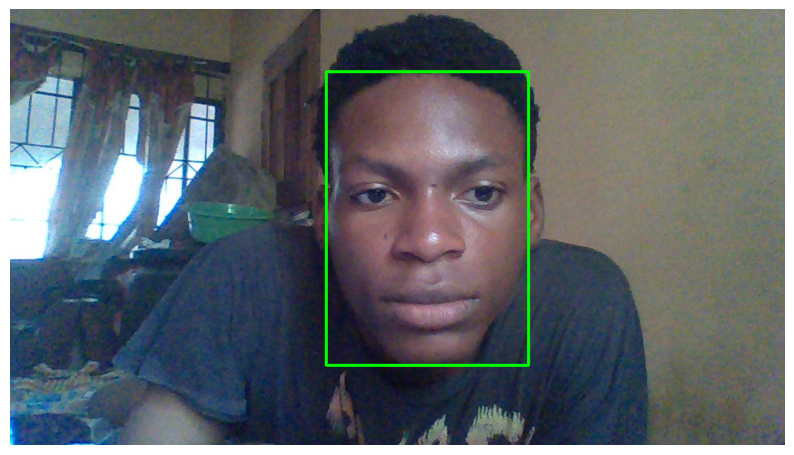

In [12]:
import cv2
import matplotlib.pyplot as plt

# Make a copy so we don't modify the original
image_with_box = image.copy()

# Get bounding box
bbox = face["bbox"].astype(int)

x1, y1, x2, y2 = bbox

# Draw rectangle
cv2.rectangle(
    image_with_box,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    3
)

# OpenCV BGR -> RGB for matplotlib
image_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [13]:
import numpy as np

embedding1 = face["embedding"]

similarity = np.dot(embedding1, embedding1) / (
    np.linalg.norm(embedding1) * np.linalg.norm(embedding1)
)

print("Cosine similarity:", similarity)

Cosine similarity: 1.0000001


load second image

In [14]:
image2 = cv2.imread("second_image.jpg")

image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

faces2 = app.get(image2_rgb)

print("Number of faces detected:", len(faces2))

Number of faces detected: 1


getting the second embedding


In [15]:
embedding2 = faces2[0]["embedding"]

print("Embedding shape:", embedding2.shape)

Embedding shape: (512,)


compare the two emebedding

In [16]:
similarity = np.dot(embedding1, embedding2) / (
    np.linalg.norm(embedding1) * np.linalg.norm(embedding2)
)

print("Cosine similarity:", similarity)

Cosine similarity: 0.7682337


comapring with a totally different image to determine our embedding threshold

In [17]:
image3 = cv2.imread("different_person.jfif")

image3_rgb = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)

faces3 = app.get(image3_rgb)

print("Number of faces detected:", len(faces3))

Number of faces detected: 1


In [18]:
embedding3 = faces3[0]["embedding"]

print("Embedding shape:", embedding3.shape)

Embedding shape: (512,)


In [19]:
similarity_different = np.dot(embedding1, embedding3) / (
    np.linalg.norm(embedding1) * np.linalg.norm(embedding3)
)

print("Cosine similarity (different person):", similarity_different)

Cosine similarity (different person): 0.08801156


Create an resuable function

In [20]:
def cosine_similarity(embedding1, embedding2):
    return np.dot(embedding1, embedding2) / (
        np.linalg.norm(embedding1) * np.linalg.norm(embedding2)
    )

In [21]:
same_person_score = cosine_similarity(embedding1, embedding2)
different_person_score = cosine_similarity(embedding1, embedding3)

print("Same person:", same_person_score)
print("Different person:", different_person_score)

Same person: 0.7682337
Different person: 0.08801156


Create an employee record

In [22]:
employee_database = {
    "EMP001": {
        "name": "Employee 1",
        "embeddings": []
    }
}

print(employee_database)

{'EMP001': {'name': 'Employee 1', 'embeddings': []}}


Add our two embeddings

In [23]:
employee_database["EMP001"]["embeddings"].append(embedding1)
employee_database["EMP001"]["embeddings"].append(embedding2)

print(
    "Number of embeddings:",
    len(employee_database["EMP001"]["embeddings"])
)

Number of embeddings: 2


Let's create the recognition function

In [24]:
def find_best_match(query_embedding, employee_database):

    best_employee = None
    best_score = -1

    for employee_id, employee_info in employee_database.items():

        for stored_embedding in employee_info["embeddings"]:

            score = cosine_similarity(
                query_embedding,
                stored_embedding
            )

            if score > best_score:
                best_score = score
                best_employee = employee_id

    return best_employee, best_score

In [25]:
employee_id, score = find_best_match(
    embedding2,
    employee_database
)

print("Best employee:", employee_id)
print("Similarity:", score)

Best employee: EMP001
Similarity: 1.0


In [26]:
test_database = {
    "EMP001": {
        "name": "Employee 1",
        "embeddings": [embedding1]
    }
}

employee_id, score = find_best_match(
    embedding2,
    test_database
)

print("Best employee:", employee_id)
print("Similarity:", score)

Best employee: EMP001
Similarity: 0.7682337


Add a recognition threshold

Let's create a function that takes the best similarity and decides whether to accept it.

For now, we'll use 0.60 only as an experimental threshold, not our final production thr

In [27]:
THRESHOLD = 0.60

def recognize_face(query_embedding, employee_database):

    employee_id, score = find_best_match(
        query_embedding,
        employee_database
    )

    if score >= THRESHOLD:
        name = employee_database[employee_id]["name"]
        return employee_id, name, score

    return None, "Unknown", score

Test a known person

In [28]:
employee_id, name, score = recognize_face(
    embedding2,
    test_database
)

print("Employee ID:", employee_id)
print("Name:", name)
print("Similarity:", score)

Employee ID: EMP001
Name: Employee 1
Similarity: 0.7682337


Test the different person

In [29]:
employee_id, name, score = recognize_face(
    embedding3,
    test_database
)

print("Employee ID:", employee_id)
print("Name:", name)
print("Similarity:", score)

Employee ID: None
Name: Unknown
Similarity: 0.08801156


Create an enrollment function

In [30]:
def enroll_employee(employee_id, name, embeddings, database):

    database[employee_id] = {
        "name": name,
        "embeddings": embeddings
    }

    print(f"{name} enrolled successfully.")
    print(f"Number of embeddings: {len(embeddings)}")

Enroll our test employee

In [31]:
enroll_employee(
    "EMP001",
    "Employee 1",
    [embedding1, embedding2],
    employee_database
)

Employee 1 enrolled successfully.
Number of embeddings: 2


In [32]:
print(employee_database.keys())

dict_keys(['EMP001'])


In [33]:
print(employee_database["EMP001"]["name"])
print(len(employee_database["EMP001"]["embeddings"]))

Employee 1
2


ADD A SECOND EMPLOYEE

In [34]:
enroll_employee(
    "EMP002",
    "Employee 2",
    [embedding3],
    employee_database
)

Employee 2 enrolled successfully.
Number of embeddings: 1


In [35]:
print(employee_database.keys())

dict_keys(['EMP001', 'EMP002'])


In [36]:
employee_id, name, score = recognize_face(
    embedding2,
    employee_database
)

print("Employee ID:", employee_id)
print("Name:", name)
print("Similarity:", score)

Employee ID: EMP001
Name: Employee 1
Similarity: 1.0


Build an automatic enrollment pipeline

In [37]:
def get_face_embedding(image_path):

    # 1. Read image
    image = cv2.imread(image_path)

    # Check if image was loaded
    if image is None:
        print("Could not read image.")
        return None

    # 2. Convert BGR → RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 3. Detect face
    faces = app.get(image_rgb)

    # 4. Make sure exactly one face was found
    if len(faces) == 0:
        print("No face detected.")
        return None

    if len(faces) > 1:
        print("More than one face detected.")
        return None

    # 5. Extract embedding
    embedding = faces[0]["embedding"]

    return embedding

Now let's make enrollment automatic

In [38]:
def enroll_employee_from_images(employee_id, name, image_paths, database):

    embeddings = []

    for image_path in image_paths:

        embedding = get_face_embedding(image_path)

        if embedding is not None:
            embeddings.append(embedding)

    if len(embeddings) == 0:
        print("Enrollment failed: no valid faces found.")
        return

    database[employee_id] = {
        "name": name,
        "embeddings": embeddings
    }

    print(f"{name} enrolled successfully.")
    print(f"Valid images: {len(embeddings)}")

In [39]:
embedding_test = get_face_embedding("/content/second_image.jpg")

print("Embedding shape:", embedding_test.shape)
print("First 5 values:", embedding_test[:5])

Embedding shape: (512,)
First 5 values: [-0.48436746  0.35872614 -0.5646053   0.28498295  0.22197542]


Create the folder structure

In [40]:
import os

os.makedirs("/content/employees/EMP001", exist_ok=True)
os.makedirs("/content/employees/EMP002", exist_ok=True)

In [41]:
import glob
import os

employee_folder = "/content/employees"

for employee_id in os.listdir(employee_folder):

    employee_path = os.path.join(
        employee_folder,
        employee_id
    )

    # Create an empty list for this employee's images
    image_paths = []

    # Look for all supported image formats
    for extension in ["*.jpg", "*.jpeg", "*.jfif", "*.png"]:
        image_paths.extend(
            glob.glob(
                os.path.join(employee_path, extension)
            )
        )

    print(employee_id, image_paths)

EMP001 []
EMP002 []


In [42]:
def enroll_all_employees(employee_folder, database):

    for employee_id in os.listdir(employee_folder):

        employee_path = os.path.join(
            employee_folder,
            employee_id
        )

        # Skip files; we only want employee folders
        if not os.path.isdir(employee_path):
            continue

        # Find all supported image formats
        image_paths = []

        for extension in ["*.jpg", "*.jpeg", "*.jfif", "*.png"]:
            image_paths.extend(
                glob.glob(
                    os.path.join(employee_path, extension)
                )
            )

        embeddings = []

        print(f"\nProcessing {employee_id}...")

        for image_path in image_paths:

            print("  Processing:", os.path.basename(image_path))

            embedding = get_face_embedding(image_path)

            if embedding is not None:
                embeddings.append(embedding)

        # Store employee if at least one valid face was found
        if len(embeddings) > 0:

            database[employee_id] = {
                "name": employee_id,
                "embeddings": embeddings
            }

            print(
                f"✓ {employee_id} enrolled "
                f"with {len(embeddings)} embeddings."
            )

        else:
            print(
                f"✗ {employee_id}: no valid faces found."
            )

In [43]:
enroll_all_employees(
    "/content/employees",
    employee_database
)


Processing EMP001...
✗ EMP001: no valid faces found.

Processing EMP002...
✗ EMP002: no valid faces found.


In [44]:
for employee_id, employee_info in employee_database.items():

    print("\nEmployee ID:", employee_id)
    print("Name:", employee_info["name"])
    print("Number of embeddings:", len(employee_info["embeddings"]))
    print("Embedding shape:", employee_info["embeddings"][0].shape)


Employee ID: EMP001
Name: Employee 1
Number of embeddings: 2
Embedding shape: (512,)

Employee ID: EMP002
Name: Employee 2
Number of embeddings: 1
Embedding shape: (512,)


Create a function to recognize an image

In [45]:
def recognize_image(image_path, database):

    # Get the face embedding from the new image
    query_embedding = get_face_embedding(image_path)

    if query_embedding is None:
        print("Could not recognize face.")
        return

    # Compare against our employee database
    employee_id, name, score = recognize_face(
        query_embedding,
        database
    )

    print("Employee ID:", employee_id)
    print("Name:", name)
    print("Similarity:", score)

In [46]:
recognize_image(
    "/content/employees/EMP001/image1.jpg",
    employee_database
)

Could not read image.
Could not recognize face.


Test with a different photo of EMP001

In [47]:
recognize_image(
    "/content/test_image1.jpg",
    employee_database
)

Employee ID: EMP001
Name: Employee 1
Similarity: 0.68971896


test unknown image

In [48]:
recognize_image(
    "/content/unknown_image.jpg",
    employee_database
)

Employee ID: None
Name: Unknown
Similarity: 0.26782835


creating a function that displays the face and identity

In [49]:
def recognize_and_display(image_path, database):

    # Read image
    image = cv2.imread(image_path)

    if image is None:
        print("Could not read image.")
        return

    # Convert to RGB for InsightFace
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Detect faces
    faces = app.get(image_rgb)

    if len(faces) == 0:
        print("No face detected.")
        return

    # Process every detected face
    for face in faces:

        # Get the embedding
        query_embedding = face["embedding"]

        # Find best employee match
        employee_id, name, score = recognize_face(
            query_embedding,
            database
        )

        # Get bounding box
        x1, y1, x2, y2 = face["bbox"].astype(int)

        # Decide what text to display
        if employee_id is not None:
            label = f"{name} ({score:.2f})"
        else:
            label = f"Unknown ({score:.2f})"

        # Draw rectangle
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Draw name
        cv2.putText(
            image,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    # Convert BGR → RGB for displaying in Colab
    image_rgb_display = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Display image
    from matplotlib import pyplot as plt

    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb_display)
    plt.axis("off")
    plt.show()

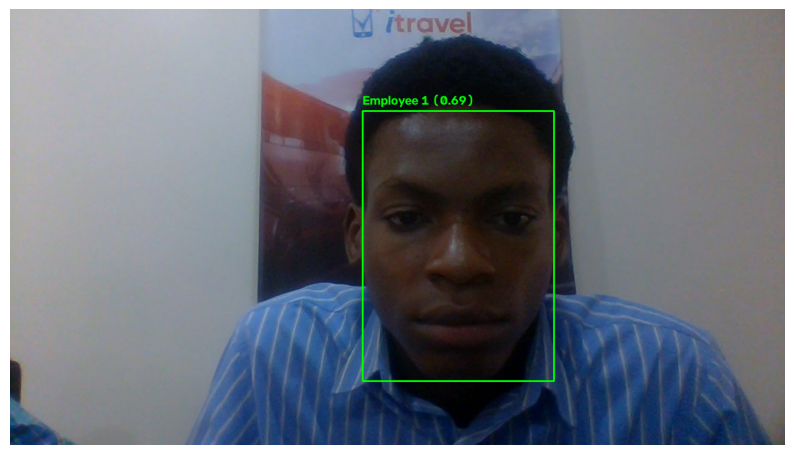

In [50]:
recognize_and_display(
    "/content/test_image1.jpg",
    employee_database
)

Test a webcam snapshot

In [51]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

In [52]:
def take_photo(filename="webcam_photo.jpg", quality=0.8):

    js = Javascript("""
    async function takePhoto(quality) {

        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;

        await video.play();

        // Wait briefly for the camera to initialize
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0
        );

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL(
            'image/jpeg',
            quality
        );
    }

    """)

    display(js)

    data = eval_js(
        f"takePhoto({quality})"
    )

    binary = b64decode(
        data.split(',')[1]
    )

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename

TAKE A PHOTO

In [54]:
photo_path = take_photo()

print("Photo saved to:", photo_path)

<IPython.core.display.Javascript object>

Photo saved to: webcam_photo.jpg


Send that photo through your recognition system

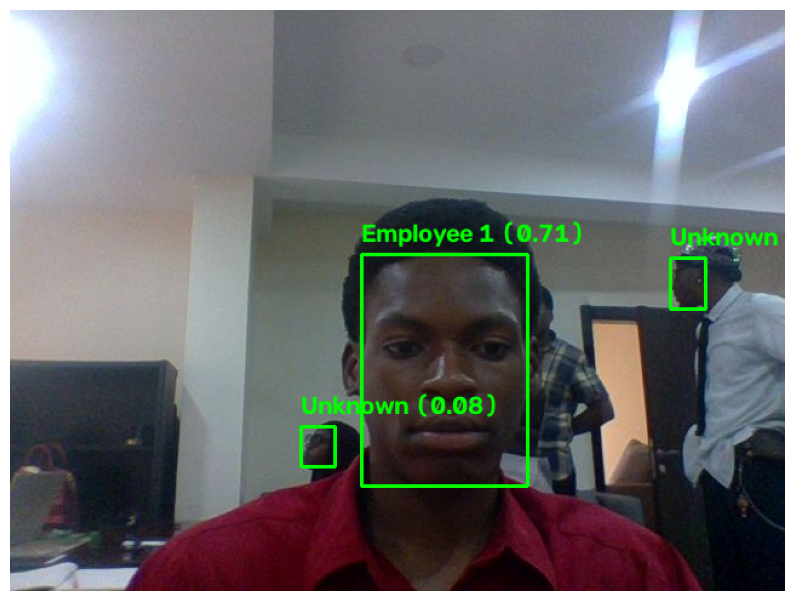

In [55]:
recognize_and_display(
    photo_path,
    employee_database
)

First, let's make a real-time webcam loop

Because you're using Colab, we'll use the browser camera rather than cv2.VideoCapture(0).

In [56]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
import matplotlib.pyplot as plt

Then we'll build the webcam interface

In [57]:
def start_webcam():

    js = Javascript("""
    async function startCamera() {

        const div = document.createElement('div');

        const video = document.createElement('video');

        video.style.display = 'block';
        video.width = 640;
        video.height = 480;

        const stream = await navigator.mediaDevices.getUserMedia({
            video: {
                width: 640,
                height: 480
            }
        });

        video.srcObject = stream;

        document.body.appendChild(div);
        div.appendChild(video);

        await video.play();

        window.cameraVideo = video;
        window.cameraStream = stream;

        return true;
    }

    startCamera();
    """)

    display(js)

In [58]:
start_webcam()

<IPython.core.display.Javascript object>

Capture one frame from the running webcam

In [59]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

In [60]:
def capture_frame():

    js = Javascript("""
    async function captureFrame() {

        const video = window.cameraVideo;

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0
        );

        return canvas.toDataURL('image/jpeg');
    }

    captureFrame();
    """)

    display(js)

    data = eval_js("captureFrame()")

    binary = b64decode(data.split(',')[1])

    frame = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame,
        cv2.IMREAD_COLOR
    )

    return frame

Capture and display a frame

In [61]:
frame = capture_frame()

print("Frame shape:", frame.shape)

<IPython.core.display.Javascript object>

MessageError: TypeError: Cannot read properties of undefined (reading 'videoWidth')

Restart the webcam with a more reliable JavaScript setup

In [62]:
from IPython.display import display, Javascript
from google.colab.output import eval_js

def start_webcam():

    js = Javascript("""
    async function startCamera() {

        // Remove previous camera if one exists
        if (window.cameraStream) {
            window.cameraStream.getTracks().forEach(
                track => track.stop()
            );
        }

        const div = document.createElement('div');
        div.id = 'webcam-container';

        const video = document.createElement('video');

        video.width = 640;
        video.height = 480;
        video.autoplay = true;

        const stream =
            await navigator.mediaDevices.getUserMedia({
                video: true
            });

        video.srcObject = stream;

        document.body.appendChild(div);
        div.appendChild(video);

        await video.play();

        // Store them globally
        window.cameraVideo = video;
        window.cameraStream = stream;

        return "Camera started";
    }

    startCamera();
    """)

    display(js)

In [63]:
start_webcam()

<IPython.core.display.Javascript object>

In [64]:
def capture_frame():

    js = Javascript("""
    async function getFrame() {

        const video = window.cameraVideo;

        if (!video) {
            throw new Error("Camera is not running.");
        }

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        return canvas.toDataURL('image/jpeg');
    }

    """)

    display(js)

    data = eval_js("getFrame()")

    binary = b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

In [65]:
from base64 import b64decode
import numpy as np
import cv2

In [66]:
frame = capture_frame()

print("Frame shape:", frame.shape)

<IPython.core.display.Javascript object>

MessageError: Error: Camera is not running.

Run this replacement function

In [67]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def take_webcam_frame():

    js = Javascript("""
    async function takeFrame() {

        const video = document.createElement('video');

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        // Give the camera time to initialize
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        // Stop camera
        stream.getVideoTracks()[0].stop();

        return canvas.toDataURL('image/jpeg');
    }

    takeFrame();
    """)

    display(js)

    data = eval_js("takeFrame()")

    binary = b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

In [68]:
frame = take_webcam_frame()

print("Frame shape:", frame.shape)

<IPython.core.display.Javascript object>

Frame shape: (480, 640, 3)


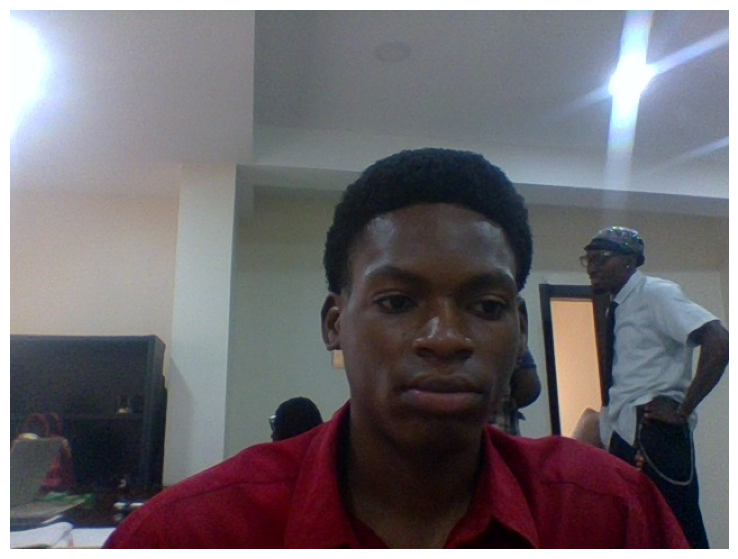

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()

Run this function to completely stop/remove the camera

In [70]:
def stop_webcam():

    js = Javascript("""
    (() => {

        // Stop any active camera tracks
        if (window.cameraStream) {
            window.cameraStream
                .getTracks()
                .forEach(track => track.stop());

            window.cameraStream = null;
        }

        // Remove any video elements created by the webcam
        document
            .querySelectorAll('video')
            .forEach(video => video.remove());

        // Remove webcam container if it exists
        const container =
            document.getElementById('webcam-container');

        if (container) {
            container.remove();
        }

        return "Webcam stopped";
    })();
    """)

    display(js)

In [71]:
stop_webcam()

<IPython.core.display.Javascript object>

In [72]:
from IPython.display import Javascript, display
from google.colab.output import eval_js

def force_stop_camera():

    js = Javascript("""
    (() => {

        // Stop tracks from every video element
        document.querySelectorAll('video').forEach(video => {

            if (video.srcObject) {

                video.srcObject
                    .getTracks()
                    .forEach(track => track.stop());

                video.srcObject = null;
            }

            video.remove();
        });

        // Stop our saved stream if it exists
        if (window.cameraStream) {

            window.cameraStream
                .getTracks()
                .forEach(track => track.stop());

            window.cameraStream = null;
        }

        window.cameraVideo = null;

        return "All camera streams stopped";
    })();
    """)

    display(js)

force_stop_camera()

<IPython.core.display.Javascript object>

creating funvtio for continuos web capturing

In [73]:
def recognize_frame(frame, database):

    # Convert OpenCV BGR → RGB
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Detect faces
    faces = app.get(frame_rgb)

    # Process every detected face
    for face in faces:

        # Get the 512-dimensional embedding
        query_embedding = face["embedding"]

        # Compare against employee database
        employee_id, name, score = recognize_face(
            query_embedding,
            database
        )

        # Get bounding box
        x1, y1, x2, y2 = face["bbox"].astype(int)

        # Decide what label to display
        if employee_id is not None:

            label = f"{name} | {score:.2f}"

        else:

            label = f"Unknown | {score:.2f}"

        # Draw bounding box
        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Draw label
        cv2.putText(
            frame,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    return frame

Test it with the webcam frame you already captured

In [74]:
recognized_frame = recognize_frame(
    frame,
    employee_database
)

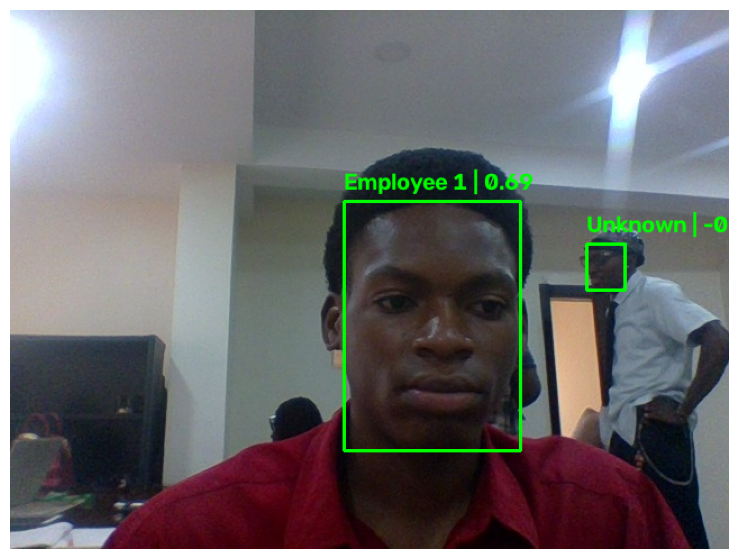

In [75]:
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

In [76]:
employee_database["EMP001"]["name"] = "Uche emmanuel"
employee_database["EMP002"]["name"] = "Anok yai"

In [77]:
for employee_id, employee_info in employee_database.items():
    print(employee_id, "→", employee_info["name"])

EMP001 → Uche emmanuel
EMP002 → Anok yai


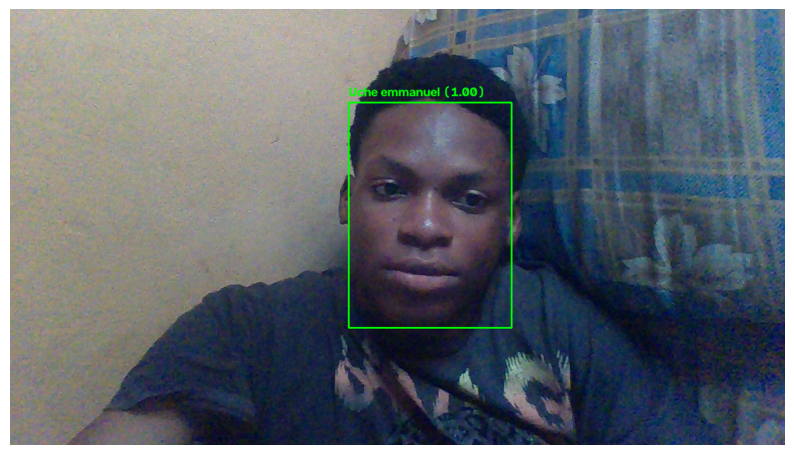

In [78]:
recognize_and_display(
    "/content/second_image.jpg",
    employee_database
)

Test one more webcam frame

<IPython.core.display.Javascript object>

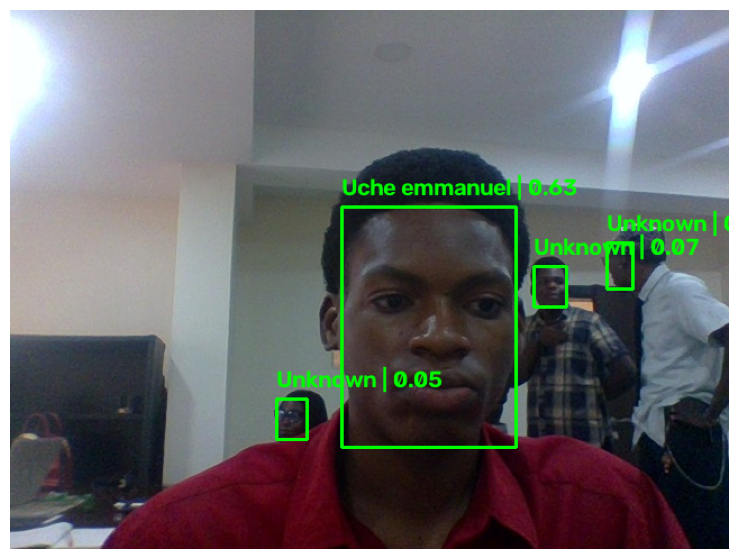

In [79]:
frame = take_webcam_frame()

recognized_frame = recognize_frame(
    frame,
    employee_database
)

plt.figure(figsize=(10, 7))
plt.imshow(
    cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

<IPython.core.display.Javascript object>

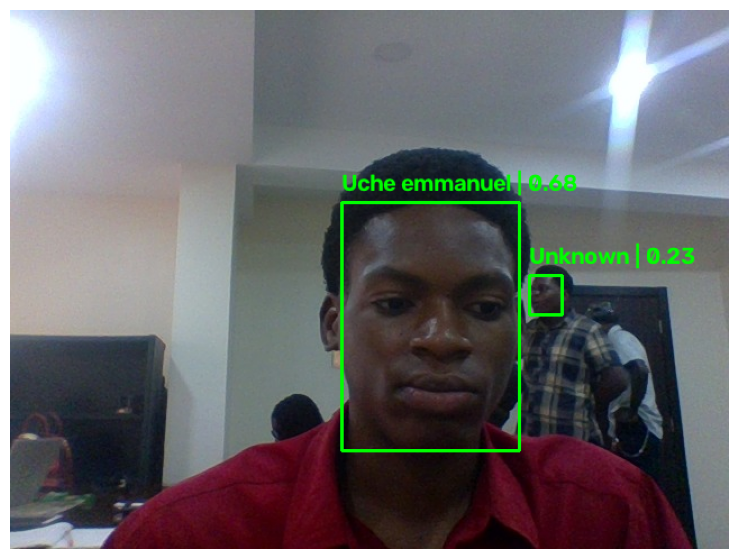

In [80]:
frame = take_webcam_frame()

recognized_frame = recognize_frame(
    frame,
    employee_database
)

plt.figure(figsize=(10, 7))
plt.imshow(
    cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.show()

create a continous camera function

In [81]:
from IPython.display import display, Javascript
from google.colab import output
import base64
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [82]:
def start_live_camera():

    js = Javascript("""
    async function startLiveCamera() {

        const container = document.createElement('div');

        const video = document.createElement('video');

        video.width = 640;
        video.height = 480;
        video.autoplay = true;

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        container.appendChild(video);
        document.body.appendChild(container);

        window.liveVideo = video;
        window.liveStream = stream;

        return "Camera started";
    }

    startLiveCamera();
    """)

    display(js)

start the camera

In [83]:
start_live_camera()

<IPython.core.display.Javascript object>

capture a frame from the live camera

In [84]:
def get_live_frame():

    js = Javascript("""
    async function getLiveFrame() {

        const video = window.liveVideo;

        if (!video) {
            throw new Error("Live camera is not running.");
        }

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        return canvas.toDataURL('image/jpeg');
    }

    """)

    display(js)

    data = output.eval_js("getLiveFrame()")

    binary = base64.b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

checking a frame from our live camera

In [85]:
frame = get_live_frame()

print("Frame shape:", frame.shape)

<IPython.core.display.Javascript object>

MessageError: Error: Live camera is not running.

based on our error we are chaning our javescript file

Stop any old camera streams

In [ ]:
from IPython.display import Javascript, display

display(Javascript("""
(() => {
    document.querySelectorAll('video').forEach(video => {
        if (video.srcObject) {
            video.srcObject.getTracks().forEach(track => track.stop());
            video.srcObject = null;
        }
        video.remove();
    });
    return "Camera stopped";
})();
"""))

Start the camera and capture in the same JavaScript session

Replace our previous start_live_camera() and get_live_frame()

In [ ]:
from IPython.display import display, Javascript
from google.colab import output
import base64
import cv2
import numpy as np

def take_live_frame():

    js = Javascript("""
    async function captureCameraFrame() {

        const video = document.createElement('video');

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        // Give the camera a moment to produce a frame
        await new Promise(resolve => setTimeout(resolve, 1000));

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        const image = canvas.toDataURL('image/jpeg');

        // Stop camera
        stream.getTracks().forEach(track => track.stop());

        return image;
    }

    captureCameraFrame();
    """)

    display(js)

    data = output.eval_js("captureCameraFrame()")

    binary = base64.b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

In [ ]:
frame = take_live_frame()

print("Frame shape:", frame.shape)

our function is now working we can run the recoginitio system we created earlier

In [ ]:
recognized_frame = recognize_frame(
    frame,
    employee_database
)

display our captured frame after running it through our recongintio system

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

our recent function open the camera take an photo and close which is want we wanted but we now want to run a contiuons one for real time image recongintion

In [ ]:
from IPython.display import display, Javascript
from google.colab import output

In [ ]:
def start_camera():

    js = Javascript("""
    async function startCamera() {

        // Create video element
        const video = document.createElement('video');

        video.width = 640;
        video.height = 480;
        video.autoplay = true;

        // Ask browser for camera
        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        // Connect camera to video
        video.srcObject = stream;

        // Add video to notebook
        document.body.appendChild(video);

        // Store camera information in browser
        window.myVideo = video;
        window.myStream = stream;

        await video.play();

        return "Camera started";
    }

    startCamera();
    """)

    display(js)

In [ ]:
start_camera()

Create a frame-capture function

In [ ]:
def capture_live_frame():

    js = Javascript("""
    async function captureFrameFromCamera() {

        const video = window.myVideo;

        if (!video) {
            throw new Error("Camera is not running.");
        }

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas
            .getContext('2d')
            .drawImage(
                video,
                0,
                0,
                canvas.width,
                canvas.height
            );

        return canvas.toDataURL('image/jpeg');
    }

    """)

    display(js)

    data = output.eval_js(
        "captureFrameFromCamera()"
    )

    binary = base64.b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

capture a frame

In [ ]:
frame = capture_live_frame()

print("Frame shape:", frame.shape)

Stop the current camer

In [ ]:
from IPython.display import display, Javascript

display(Javascript("""
(() => {
    document.querySelectorAll('video').forEach(video => {
        if (video.srcObject) {
            video.srcObject.getTracks().forEach(track => track.stop());
        }
        video.remove();
    });
})();
"""))

using a new continuos javascript function

In [ ]:
from IPython.display import display, Javascript
from google.colab import output
import base64
import cv2
import numpy as np

def capture_camera_frame():

    js = Javascript("""
    async function captureCameraFrame() {

        const video = document.createElement('video');

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        video.srcObject = stream;

        await video.play();

        await new Promise(resolve => setTimeout(resolve, 500));

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        const image = canvas.toDataURL('image/jpeg');

        stream.getTracks().forEach(track => track.stop());

        return image;
    }

    captureCameraFrame();
    """)

    display(js)

    data = output.eval_js(
        "captureCameraFrame()"
    )

    binary = base64.b64decode(
        data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    return frame

testing our captured frame

In [ ]:
frame = capture_camera_frame()

print("Frame shape:", frame.shape)

Running our captured frame into our recognition system

In [ ]:
recognized_frame = recognize_frame(
    frame,
    employee_database
)

display our captured frame

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")
plt.show()

we having been capturing only one frame now lets capture at least five frame continuosly

In [ ]:
from IPython.display import display, Javascript
from google.colab import output
import base64
import cv2
import numpy as np
import matplotlib.pyplot as plt


def capture_multiple_frames(num_frames=5, delay=0.5):

    js = Javascript(f"""
    async function captureMultipleFrames() {{

        const video = document.createElement('video');

        const stream = await navigator.mediaDevices.getUserMedia({{
            video: true
        }});

        video.srcObject = stream;

        await video.play();

        await new Promise(resolve => setTimeout(resolve, 500));

        const frames = [];

        for (let i = 0; i < {num_frames}; i++) {{

            const canvas = document.createElement('canvas');

            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            canvas
                .getContext('2d')
                .drawImage(
                    video,
                    0,
                    0,
                    canvas.width,
                    canvas.height
                );

            frames.push(
                canvas.toDataURL('image/jpeg')
            );

            await new Promise(
                resolve => setTimeout(resolve, {int(delay * 1000)})
            );
        }}

        stream.getTracks().forEach(
            track => track.stop()
        );

        return frames;
    }}

    captureMultipleFrames();
    """)

    display(js)

    data = output.eval_js(
        "captureMultipleFrames()"
    )

    frames = []

    for image_data in data:

        binary = base64.b64decode(
            image_data.split(',')[1]
        )

        frame_array = np.frombuffer(
            binary,
            dtype=np.uint8
        )

        frame = cv2.imdecode(
            frame_array,
            cv2.IMREAD_COLOR
        )

        frames.append(frame)

    return frames

checking our captured frame

In [ ]:
frames = capture_multiple_frames(
    num_frames=5,
    delay=0.5
)

print("Number of frames:", len(frames))
print("Frame shape:", frames[0].shape)

running them into our recognitio system

In [ ]:
for i, frame in enumerate(frames):

    print(f"\nFrame {i + 1}")

    recognized_frame = recognize_frame(
        frame,
        employee_database
    )

    frame_rgb = cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 5))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

adding an unknown safe guard

In [ ]:
THRESHOLD = 0.60


def recognize_face(query_embedding, employee_database):

    employee_id, score = find_best_match(
        query_embedding,
        employee_database
    )

    # No employee is close enough
    if score < THRESHOLD:
        return None, "Unknown", score

    # Employee is sufficiently similar
    name = employee_database[employee_id]["name"]

    return employee_id, name, score

In [ ]:
frame = capture_camera_frame()

recognized_frame = recognize_frame(
    frame,
    employee_database
)

frame_rgb = cv2.cvtColor(
    recognized_frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 7))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

creating a call back

In [86]:
from google.colab import output
import base64
import cv2
import numpy as np

def process_camera_frame(image_data):

    # Remove the "data:image/jpeg;base64," part
    binary = base64.b64decode(
        image_data.split(',')[1]
    )

    # Convert bytes → NumPy array
    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    # Convert NumPy array → OpenCV image
    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    # Run our existing recognition system
    recognized_frame = recognize_frame(
        frame,
        employee_database
    )

    # Convert OpenCV BGR → RGB
    frame_rgb = cv2.cvtColor(
        recognized_frame,
        cv2.COLOR_BGR2RGB
    )

    return frame_rgb.tolist()


output.register_callback(
    'notebook.process_frame',
    process_camera_frame
)

print("Callback registered successfully.")

Callback registered successfully.


test the live camera

In [87]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;
    video.autoplay = true;

    document.body.appendChild(video);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: true
    });

    video.srcObject = stream;

    await video.play();

    const canvas = document.createElement('canvas');

    canvas.width = 640;
    canvas.height = 480;

    const context = canvas.getContext('2d');

    // Keep camera running
    while (true) {

        context.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        const imageData = canvas.toDataURL(
            'image/jpeg',
            0.7
        );

        await google.colab.kernel.invokeFunction(
            'notebook.process_frame',
            [imageData],
            {}
        );

        await new Promise(
            resolve => setTimeout(resolve, 500)
        );
    }

})();
"""))

<IPython.core.display.Javascript object>

creating live call back

In [88]:
import cv2
import numpy as np
import base64
from google.colab import output


def process_camera_frame(image_data):

    # Convert base64 image → bytes
    binary = base64.b64decode(
        image_data.split(',')[1]
    )

    # Convert bytes → NumPy array
    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    # Convert bytes → OpenCV image
    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    # Run face recognition
    recognized_frame = recognize_frame(
        frame,
        employee_database
    )

    # Compress processed frame to JPEG
    success, buffer = cv2.imencode(
        '.jpg',
        recognized_frame
    )

    if not success:
        return None

    # Convert JPEG → base64
    encoded = base64.b64encode(
        buffer
    ).decode('utf-8')

    return encoded


output.register_callback(
    'notebook.process_frame',
    process_camera_frame
)

print("Live recognition callback ready.")

Live recognition callback ready.


starting the live recogniton system

In [89]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    // Create video element
    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;
    video.autoplay = true;

    document.body.appendChild(video);

    // Create output image
    const outputImage = document.createElement('img');

    outputImage.width = 640;
    outputImage.height = 480;

    document.body.appendChild(outputImage);

    // Open webcam
    const stream = await navigator.mediaDevices.getUserMedia({
        video: true
    });

    video.srcObject = stream;

    await video.play();

    // Canvas used to capture frames
    const canvas = document.createElement('canvas');

    canvas.width = 640;
    canvas.height = 480;

    const context = canvas.getContext('2d');

    console.log("Live recognition started");

    while (true) {

        // Capture current camera frame
        context.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Convert frame to JPEG
        const imageData = canvas.toDataURL(
            'image/jpeg',
            0.6
        );

        // Send frame to Python
        const result = await google.colab.kernel.invokeFunction(
            'notebook.process_frame',
            [imageData],
            {}
        );

        // Get processed JPEG
        const processedImage = result.data;

        if (processedImage) {

            outputImage.src =
                'data:image/jpeg;base64,' +
                processedImage;
        }

        // Small delay
        await new Promise(
            resolve => setTimeout(resolve, 300)
        );
    }

})();
"""))

<IPython.core.display.Javascript object>

In [90]:
from google.colab import output
import base64
import cv2
import numpy as np


def process_camera_frame(image_data):

    # Decode the incoming camera image
    binary = base64.b64decode(
        image_data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    # Run your existing face recognition
    recognized_frame = recognize_frame(
        frame,
        employee_database
    )

    # Encode processed frame as JPEG
    success, buffer = cv2.imencode(
        '.jpg',
        recognized_frame
    )

    if not success:
        return ""

    # Convert JPEG to base64
    encoded_image = base64.b64encode(
        buffer
    ).decode('utf-8')

    # Return ONLY the base64 string
    return encoded_image


output.register_callback(
    'notebook.process_frame',
    process_camera_frame
)

print("Callback ready.")

Callback ready.


In [91]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;
    video.autoplay = true;

    document.body.appendChild(video);

    const stream =
        await navigator.mediaDevices.getUserMedia({
            video: true
        });

    video.srcObject = stream;

    await video.play();

    const canvas = document.createElement('canvas');

    canvas.width = 640;
    canvas.height = 480;

    const context = canvas.getContext('2d');

    // Create the processed output image
    const outputImage = document.createElement('img');

    outputImage.width = 640;
    outputImage.height = 480;

    document.body.appendChild(outputImage);

    console.log("Live recognition started");

    while (true) {

        // Capture frame
        context.drawImage(
            video,
            0,
            0,
            canvas.width,
            canvas.height
        );

        // Convert frame to JPEG
        const imageData = canvas.toDataURL(
            'image/jpeg',
            0.6
        );

        // Send frame to Python
        const result =
            await google.colab.kernel.invokeFunction(
                'notebook.process_frame',
                [imageData],
                {}
            );

        // Get returned base64 image
        const processedImage = result.data;

        if (processedImage) {

            outputImage.src =
                'data:image/jpeg;base64,' +
                processedImage;
        }

        // Wait before processing next frame
        await new Promise(
            resolve => setTimeout(resolve, 500)
        );
    }

})();
"""))

<IPython.core.display.Javascript object>

In [92]:
from google.colab import output

def test_callback():
    return "HELLO FROM PYTHON"

output.register_callback(
    'notebook.test_callback',
    test_callback
)

print("Test callback registered.")

Test callback registered.


In [93]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.test_callback',
            [],
            {}
        );

    document.body.insertAdjacentHTML(
        'beforeend',
        '<h2>Type: ' + typeof result.data + '</h2>' +
        '<h2>Value: ' + JSON.stringify(result.data) + '</h2>'
    );

})();
"""))

<IPython.core.display.Javascript object>

In [94]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.test_callback',
            [],
            {}
        );

    const value =
        result.data["text/plain"];

    document.body.insertAdjacentHTML(
        'beforeend',
        '<h2>Python returned: ' + value + '</h2>'
    );

})();
"""))

<IPython.core.display.Javascript object>

Now let's fix the live recognition properly. Instead of sending the processed image back from Python—which is what was causing the empty image box—we'll have Python return only:

the person's name
similarity score
bounding-box coordinates

Then JavaScript will draw the box directly over the live camera.

Create the lightweight Python callback

In [95]:
from google.colab import output
import base64
import cv2
import numpy as np


def process_camera_frame(image_data):

    # -----------------------------
    # 1. Decode the camera image
    # -----------------------------

    binary = base64.b64decode(
        image_data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )


    # -----------------------------
    # 2. Detect faces
    # -----------------------------

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    faces = app.get(frame_rgb)


    # -----------------------------
    # 3. Store recognition results
    # -----------------------------

    results = []


    for face in faces:

        # Get this face's embedding
        query_embedding = face["embedding"]


        # Recognize the person
        employee_id, name, score = recognize_face(
            query_embedding,
            employee_database
        )


        # Get bounding box
        x1, y1, x2, y2 = face["bbox"].astype(int)


        # Store only the information
        # JavaScript needs
        results.append({
            "name": name,
            "score": float(score),
            "bbox": [
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ]
        })


    # Return recognition information
    return results


output.register_callback(
    'notebook.process_camera_frame',
    process_camera_frame
)

print("Live recognition callback registered.")

Live recognition callback registered.


In [96]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.process_camera_frame',
            [
                "data:image/jpeg;base64,"
            ],
            {}
        );

    console.log(result);

})();
"""))

<IPython.core.display.Javascript object>

start the live recognition system

In [97]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    // -----------------------------
    // Create video element
    // -----------------------------

    const video = document.createElement('video');

    video.width = 640;
    video.height = 480;

    video.autoplay = true;

    video.style.display = 'block';

    document.body.appendChild(video);


    // -----------------------------
    // Create overlay canvas
    // -----------------------------

    const canvas = document.createElement('canvas');

    canvas.width = 640;
    canvas.height = 480;

    canvas.style.position = 'absolute';
    canvas.style.left = '0px';
    canvas.style.top = '0px';

    canvas.style.pointerEvents = 'none';

    document.body.appendChild(canvas);

    const ctx = canvas.getContext('2d');


    // -----------------------------
    // Start camera
    // -----------------------------

    const stream =
        await navigator.mediaDevices.getUserMedia({
            video: true
        });

    video.srcObject = stream;

    await video.play();


    // -----------------------------
    // Create capture canvas
    // -----------------------------

    const captureCanvas =
        document.createElement('canvas');

    captureCanvas.width = 640;
    captureCanvas.height = 480;

    const captureContext =
        captureCanvas.getContext('2d');


    console.log("Live recognition started");


    // -----------------------------
    // Recognition loop
    // -----------------------------

    while (true) {

        // Capture current video frame
        captureContext.drawImage(
            video,
            0,
            0,
            640,
            480
        );


        // Convert frame to JPEG
        const imageData =
            captureCanvas.toDataURL(
                'image/jpeg',
                0.6
            );


        // Send frame to Python
        const result =
            await google.colab.kernel.invokeFunction(
                'notebook.process_camera_frame',
                [imageData],
                {}
            );


        // Get the returned Python object
        const data =
            result.data;


        // Clear previous boxes
        ctx.clearRect(
            0,
            0,
            canvas.width,
            canvas.height
        );


        // Get recognition results
        let detections = [];


        if (
            data &&
            data["application/vnd.google.colaboratory.intrinsic+json"]
        ) {

            // Colab wraps the returned Python object.
            // For now well inspect the actual value.
            console.log(data);

        }


        // Wait before processing next frame
        await new Promise(
            resolve => setTimeout(resolve, 500)
        );
    }

})();
"""))

<IPython.core.display.Javascript object>

In [98]:
import base64
import cv2

success, buffer = cv2.imencode(
    ".jpg",
    frame
)

test_image_data = (
    "data:image/jpeg;base64,"
    + base64.b64encode(buffer).decode("utf-8")
)

print("Test image prepared.")

Test image prepared.


In [99]:
from google.colab import output

def simple_result():
    return {
        "name": "Test Person",
        "score": 0.95,
        "bbox": [100, 100, 300, 300]
    }

output.register_callback(
    'notebook.simple_result',
    simple_result
)

print("Simple callback ready.")


Simple callback ready.


In [100]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.simple_result',
            [],
            {}
        );

    console.log("FULL RESULT:", result);

    document.body.insertAdjacentHTML(
        'beforeend',
        '<pre>' +
        JSON.stringify(result, null, 2) +
        '</pre>'
    );

})();
"""))

<IPython.core.display.Javascript object>

Replace the callback

In [101]:
from google.colab import output
import json
import base64
import cv2
import numpy as np


def process_camera_frame(image_data):

    # Decode camera image
    binary = base64.b64decode(
        image_data.split(',')[1]
    )

    frame_array = np.frombuffer(
        binary,
        dtype=np.uint8
    )

    frame = cv2.imdecode(
        frame_array,
        cv2.IMREAD_COLOR
    )

    # Convert BGR → RGB
    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # Detect faces
    faces = app.get(frame_rgb)

    results = []

    for face in faces:

        query_embedding = face["embedding"]

        employee_id, name, score = recognize_face(
            query_embedding,
            employee_database
        )

        x1, y1, x2, y2 = face["bbox"].astype(int)

        results.append({
            "name": name,
            "score": float(score),
            "bbox": [
                int(x1),
                int(y1),
                int(x2),
                int(y2)
            ]
        })

    # Convert Python list → JSON string
    return json.dumps(results)


output.register_callback(
    'notebook.process_camera_frame',
    process_camera_frame
)

print("Recognition callback ready.")

Recognition callback ready.


In [102]:
import base64
import cv2

success, buffer = cv2.imencode(
    ".jpg",
    frame
)

test_image_data = (
    "data:image/jpeg;base64,"
    + base64.b64encode(buffer).decode("utf-8")
)

print("Test image prepared.")

Test image prepared.


In [103]:
from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.process_camera_frame',
            [test_image_data],
            {}
        );

    const jsonText =
        result.data["text/plain"];

    const detections =
        JSON.parse(jsonText);

    console.log("Detections:", detections);

})();
"""))

<IPython.core.display.Javascript object>

In [104]:
# 1. Register the Python callback that runs face recognition on a frame
# Returns results via IPython.display.JSON so they arrive on the JS side
# as a real object under result.data['application/json'] — no manual JSON.parse needed.

from google.colab import output
from IPython.display import JSON
import base64
import cv2
import numpy as np


def process_camera_frame(image_data):

    # Decode the incoming camera frame (base64 JPEG -> OpenCV image)
    binary = base64.b64decode(image_data.split(',')[1])
    frame_array = np.frombuffer(binary, dtype=np.uint8)
    frame = cv2.imdecode(frame_array, cv2.IMREAD_COLOR)

    if frame is None:
        return JSON([])

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    faces = app.get(frame_rgb)

    results = []

    for face in faces:
        query_embedding = face["embedding"]

        employee_id, name, score = recognize_face(
            query_embedding,
            employee_database
        )

        x1, y1, x2, y2 = face["bbox"].astype(int)

        results.append({
            "name": name,
            "score": float(score),
            "bbox": [int(x1), int(y1), int(x2), int(y2)]
        })

    return JSON(results)


output.register_callback('notebook.process_camera_frame', process_camera_frame)
print("Callback registered.")

Callback registered.


In [109]:
# 2. Start the live camera with a bounding-box overlay
# Complete JS (the earlier version was cut off mid-line, which is why nothing showed).
# Click "Stop" (added to the page) to end the loop and release the camera.

from IPython.display import display, Javascript

display(Javascript("""
(async function() {

    // Clean up any previous run
    if (window.__liveRunning !== undefined) {
        window.__liveRunning = false;
    }
    document.querySelectorAll('.live-fr-container').forEach(el => el.remove());

    const container = document.createElement('div');
    container.className = 'live-fr-container';
    container.style.position = 'relative';
    container.style.width = '640px';
    container.style.height = '480px';

    const video = document.createElement('video');
    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    container.appendChild(video);

    // Transparent canvas drawn on TOP of the video for the bounding boxes
    const overlay = document.createElement('canvas');
    overlay.width = 640;
    overlay.height = 480;
    overlay.style.position = 'absolute';
    overlay.style.left = '0px';
    overlay.style.top = '0px';
    overlay.style.pointerEvents = 'none';
    container.appendChild(overlay);
    const ctx = overlay.getContext('2d');

    document.body.appendChild(container);

    const stopBtn = document.createElement('button');
    stopBtn.className = 'live-fr-container';
    stopBtn.textContent = 'Stop live recognition';
    stopBtn.style.margin = '8px 0';
    stopBtn.onclick = () => { window.__liveRunning = false; };
    document.body.appendChild(stopBtn);

    const stream = await navigator.mediaDevices.getUserMedia({ video: true });
    video.srcObject = stream;
    await video.play();

    // Hidden canvas used only to grab a JPEG snapshot to send to Python
    const captureCanvas = document.createElement('canvas');
    captureCanvas.width = 640;
    captureCanvas.height = 480;
    const captureCtx = captureCanvas.getContext('2d');

    window.__liveRunning = true;
    console.log('Live recognition started');

    while (window.__liveRunning) {

        captureCtx.drawImage(video, 0, 0, 640, 480);
        const imageData = captureCanvas.toDataURL('image/jpeg', 0.6);

        let detections = [];

        try {
            const result = await google.colab.kernel.invokeFunction(
                'notebook.process_camera_frame',
                [imageData],
                {}
            );
            detections = result.data['application/json'] || [];
        } catch (err) {
            console.error('Recognition call failed:', err);
        }

        // Redraw the overlay each frame
        ctx.clearRect(0, 0, overlay.width, overlay.height);
        ctx.lineWidth = 2;
        ctx.strokeStyle = '#00FF00';
        ctx.font = '16px sans-serif';
        ctx.fillStyle = '#00FF00';

        detections.forEach(det => {
            const [x1, y1, x2, y2] = det.bbox;
            ctx.strokeRect(x1, y1, x2 - x1, y2 - y1);
            ctx.fillText(det.name + ' (' + det.score.toFixed(2) + ')', x1, Math.max(y1 - 6, 12));
        });

        await new Promise(resolve => setTimeout(resolve, 200));
    }

    stream.getTracks().forEach(track => track.stop());
    container.remove();
    stopBtn.remove();
    console.log('Live recognition stopped, camera released.');

})();
"""))

<IPython.core.display.Javascript object>

In [106]:
# 3. (Optional) Stop the camera from a Python cell instead of the button
from IPython.display import display, Javascript

def stop_live_recognition():
    display(Javascript("window.__liveRunning = false;"))

# stop_live_recognition()